In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from stable_baselines3 import PPO
from agent import FloodWarningEnv
import random

eval_env = FloodWarningEnv()

# PPO.load causes fixed seed
model = PPO.load("./models/nonorm/final_model.zip")
np.random.seed(2)

# Runs trained agent over 10000 episodes, records action taken, tru impact level, impact score, 
# whether correct, false alarm, missed warning
def evaluate(model, env, n_episodes=100000):
    results = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        action, _ = model.predict(obs, deterministic=True)
        impact_level = env._get_impact_level(env.env.impact)
        results.append({
            "action": int(action),
            "impact_level": impact_level,
            "impact_score": env.env.impact,
            "correct": int(action) == impact_level,
            "false_alarm": int(action) > impact_level,
            "missed": int(action) < impact_level,
            "level_diff": int(action) - impact_level,
        })
    return pd.DataFrame(results)

df = evaluate(model, eval_env)

print(f"Accuracy:        {df['correct'].mean():.2%}")
print(f"False alarms:    {df['false_alarm'].mean():.2%}")
print(f"Missed warnings: {df['missed'].mean():.2%}")
print(f"Mean level diff: {df['level_diff'].mean():.3f}")
print()
print("Per impact level accuracy:")
print(df.groupby("impact_level")["correct"].mean())

Accuracy:        53.72%
False alarms:    25.36%
Missed warnings: 20.92%
Mean level diff: -0.007

Per impact level accuracy:
impact_level
0    0.643076
1    0.391148
2    0.000000
3    0.000000
Name: correct, dtype: float64


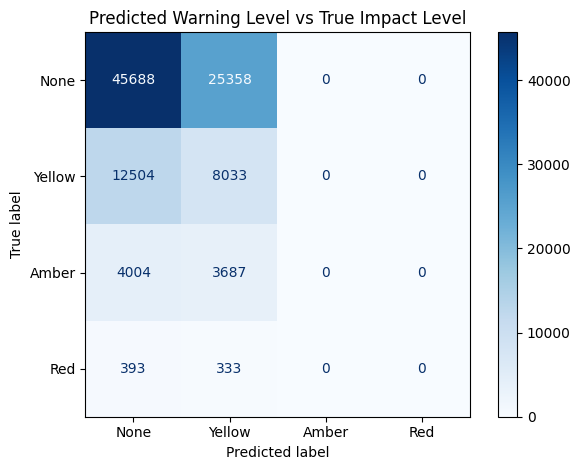

In [2]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix, shows predicted vs true warning levels
labels = ["None", "Yellow", "Amber", "Red"]
cm = confusion_matrix(df["impact_level"], df["action"], labels=[0,1,2,3])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Predicted Warning Level vs True Impact Level")
plt.tight_layout()
#plt.savefig("./results/confusion_matrix.png")
plt.show()

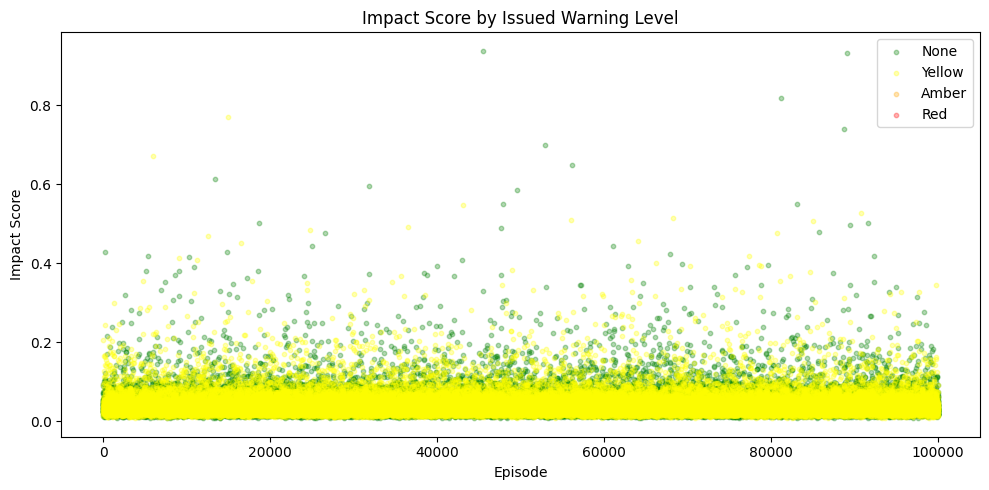

In [3]:
plt.figure(figsize=(10, 5))
colors = {0: "green", 1: "yellow", 2: "orange", 3: "red"}
for action in [0, 1, 2, 3]:
    subset = df[df["action"] == action]
    plt.scatter(subset.index, subset["impact_score"], 
                c=colors[action], label=labels[action], alpha=0.3, s=10)
plt.xlabel("Episode")
plt.ylabel("Impact Score")
plt.title("Impact Score by Issued Warning Level")
plt.legend()
plt.tight_layout()
plt.show()

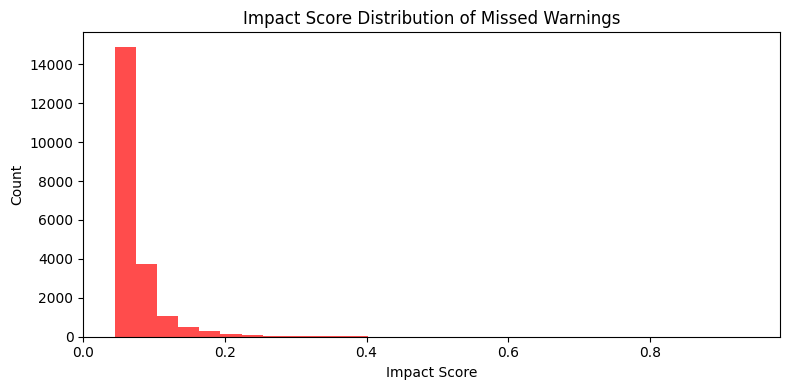

In [4]:
# Histogram of impact score for missed warnings (shows if agent missed minor events or severe ones)
missed_df = df[df["missed"]]
plt.figure(figsize=(8, 4))
plt.hist(missed_df["impact_score"], bins=30, color="red", alpha=0.7)
plt.xlabel("Impact Score")
plt.ylabel("Count")
plt.title("Impact Score Distribution of Missed Warnings")
plt.tight_layout()
#plt.savefig("./results/missed_warnings.png")
plt.show()

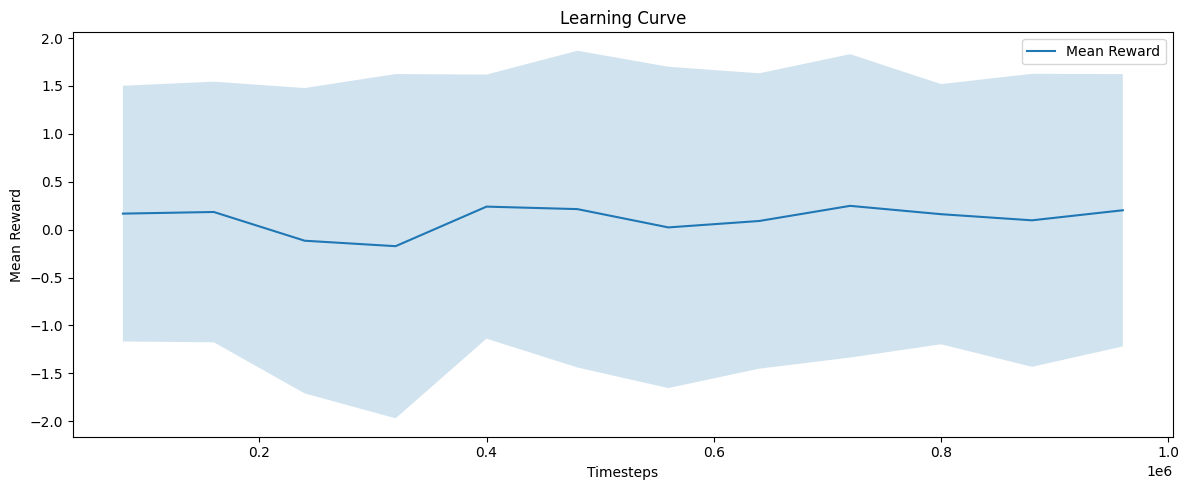

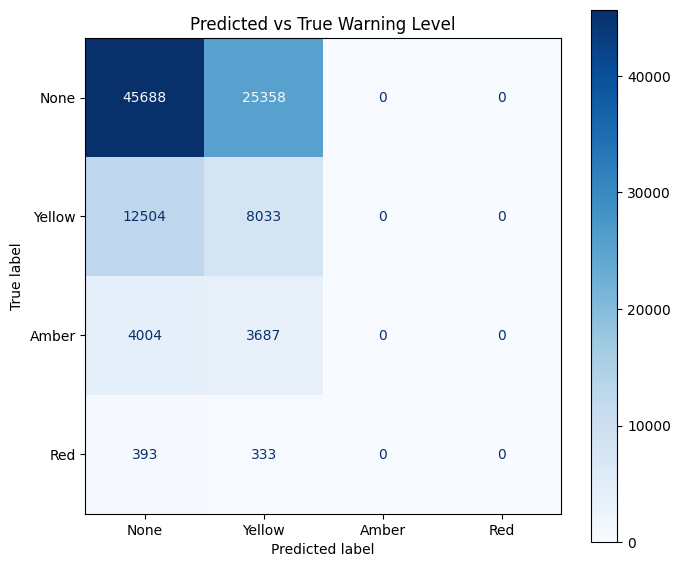

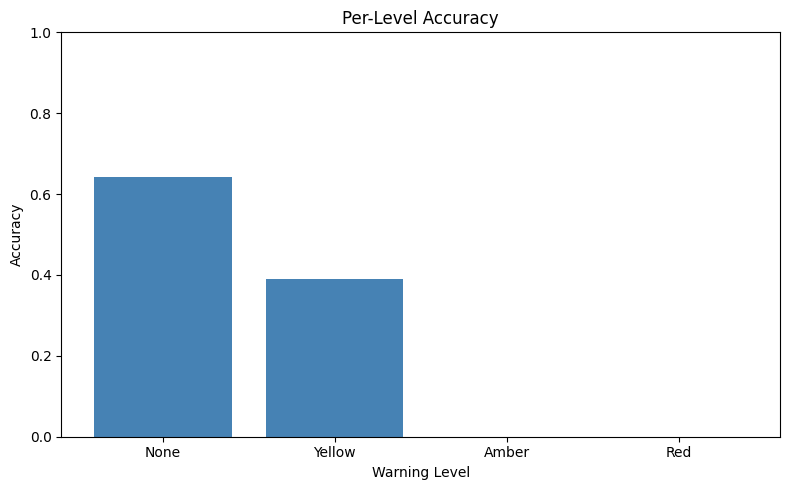

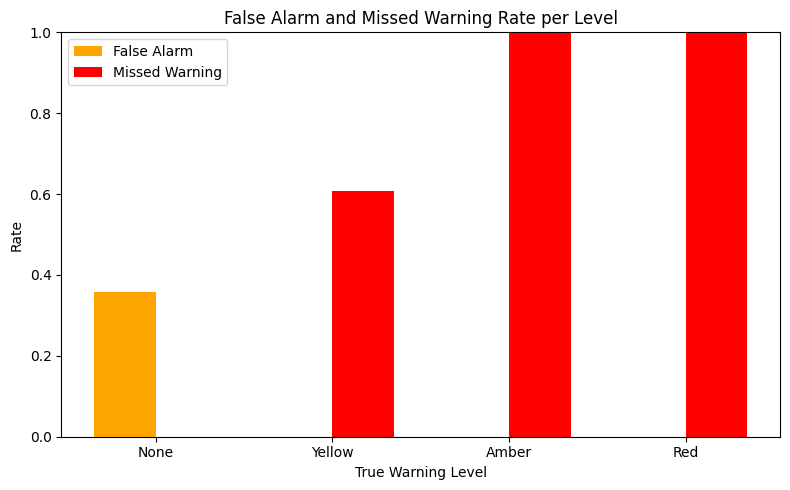

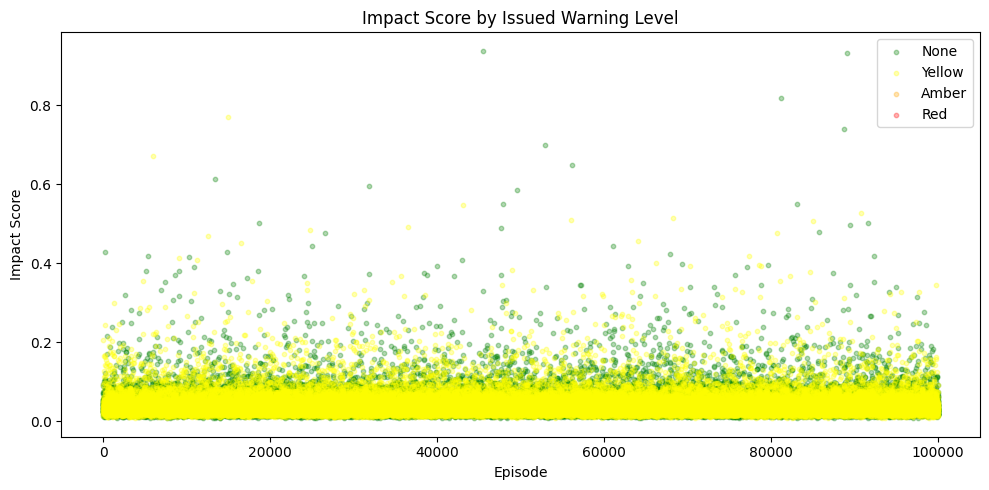

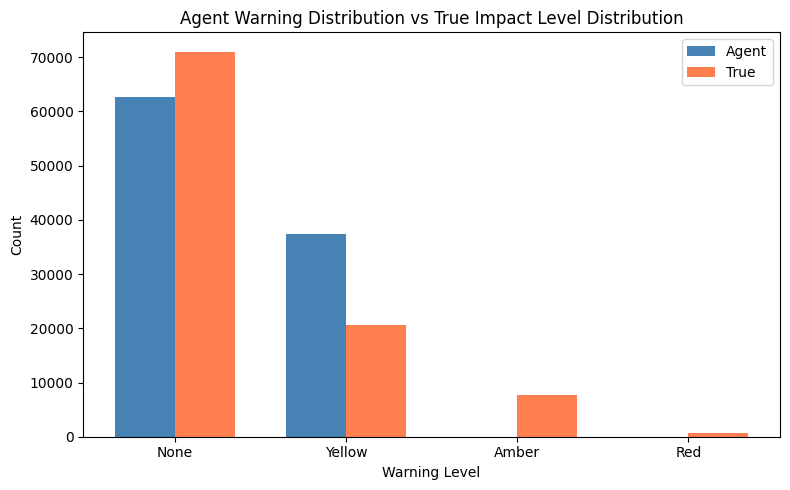

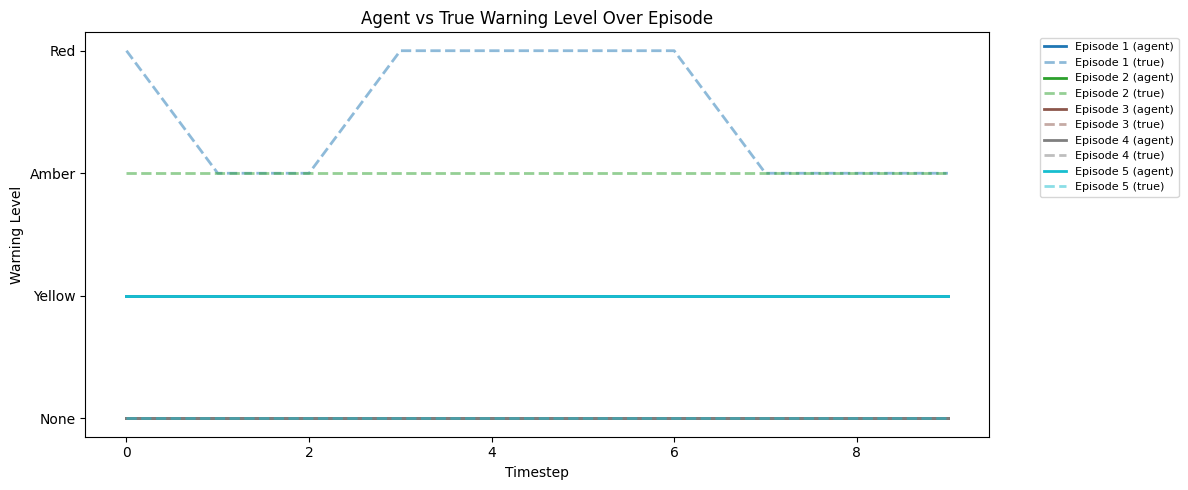

In [5]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from stable_baselines3 import PPO
from agent import FloodWarningEnv, MAX_STEPS
import os

os.makedirs("./results/", exist_ok=True)

LABELS = ["None", "Yellow", "Amber", "Red"]
COLORS = {0: "green", 1: "yellow", 2: "orange", 3: "red"}


# ── 1. LEARNING CURVE ─────────────────────────────────────────────────────────
def plot_learning_curve():
    data = np.load("./logs_OLD/vecnorm/evaluations.npz")
    timesteps = data["timesteps"]
    mean_rewards = data["results"].mean(axis=1)
    std_rewards = data["results"].std(axis=1)

    plt.figure(figsize=(12, 5))
    plt.plot(timesteps, mean_rewards, label="Mean Reward")
    plt.fill_between(timesteps, mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.2)
    plt.xlabel("Timesteps")
    plt.ylabel("Mean Reward")
    plt.title("Learning Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig("./results/learning_curve.png")
    plt.show()

# ── 2. CONFUSION MATRIX ───────────────────────────────────────────────────────
def plot_confusion_matrix():
    cm = confusion_matrix(df["impact_level"], df["action"], labels=[0, 1, 2, 3])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap="Blues", ax=ax)
    ax.set_title("Predicted vs True Warning Level")
    plt.tight_layout()
    plt.savefig("./results/confusion_matrix.png")
    plt.show()

# ── 3. PER-LEVEL ACCURACY ─────────────────────────────────────────────────────
def plot_per_level_accuracy():
    per_level = df.groupby("impact_level")["correct"].mean()
    plt.figure(figsize=(8, 5))
    plt.bar([LABELS[i] for i in per_level.index], per_level.values, color="steelblue")
    plt.xlabel("Warning Level")
    plt.ylabel("Accuracy")
    plt.title("Per-Level Accuracy")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig("./results/per_level_accuracy.png")
    plt.show()

# ── 4. FALSE ALARM AND MISSED WARNING RATE ────────────────────────────────────
def plot_false_alarm_missed():
    false_alarm = df.groupby("impact_level")["false_alarm"].mean()
    missed = df.groupby("impact_level")["missed"].mean()

    x = np.arange(len(LABELS))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, [false_alarm.get(i, 0) for i in range(4)], width, label="False Alarm", color="orange")
    ax.bar(x + width/2, [missed.get(i, 0) for i in range(4)], width, label="Missed Warning", color="red")
    ax.set_xlabel("True Warning Level")
    ax.set_ylabel("Rate")
    ax.set_title("False Alarm and Missed Warning Rate per Level")
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS)
    ax.set_ylim(0, 1)
    ax.legend()
    plt.tight_layout()
    plt.savefig("./results/false_alarm_missed.png")
    plt.show()

# ── 5. IMPACT SCORE VS ISSUED WARNING LEVEL ───────────────────────────────────
def plot_impact_vs_action():
    plt.figure(figsize=(10, 5))
    for action in [0, 1, 2, 3]:
        subset = df[df["action"] == action]
        plt.scatter(subset.index, subset["impact_score"],
                    c=COLORS[action], label=LABELS[action], alpha=0.3, s=10)
    plt.xlabel("Episode")
    plt.ylabel("Impact Score")
    plt.title("Impact Score by Issued Warning Level")
    plt.legend()
    plt.tight_layout()
    plt.savefig("./results/impact_vs_action.png")
    plt.show()

# ── 6. WARNING LEVEL DISTRIBUTION VS TRUE IMPACT LEVEL ───────────────────────
def plot_distributions():
    x = np.arange(len(LABELS))
    width = 0.35
    agent_dist = df["action"].value_counts().sort_index()
    true_dist = df["impact_level"].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, [agent_dist.get(i, 0) for i in range(4)], width, label="Agent", color="steelblue")
    ax.bar(x + width/2, [true_dist.get(i, 0) for i in range(4)], width, label="True", color="coral")
    ax.set_xlabel("Warning Level")
    ax.set_ylabel("Count")
    ax.set_title("Agent Warning Distribution vs True Impact Level Distribution")
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS)
    ax.legend()
    plt.tight_layout()
    plt.savefig("./results/distributions.png")
    plt.show()

# ── 7. EPISODE TIMESTEP PLOT ──────────────────────────────────────────────────
def plot_episode_timesteps(n_episodes=5):
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = plt.cm.tab10(np.linspace(0, 1, n_episodes))
    env = FloodWarningEnv()

    for ep_idx in range(n_episodes):
        obs, _ = env.reset()
        actions = []
        impacts = []

        for _ in range(MAX_STEPS):
            action, _ = model.predict(obs, deterministic=True)
            impact_level = env._get_impact_level(env.env.impact)
            actions.append(int(action))
            impacts.append(impact_level)
            obs, _, terminated, truncated, _ = env.step(int(action))
            if terminated or truncated:
                break

        timesteps = range(len(actions))
        ax.plot(timesteps, actions, color=colors[ep_idx], linewidth=2,
                label=f"Episode {ep_idx + 1} (agent)", linestyle="-")
        ax.plot(timesteps, impacts, color=colors[ep_idx], linewidth=2,
                linestyle="--", alpha=0.5, label=f"Episode {ep_idx + 1} (true)")

    ax.set_xlabel("Timestep")
    ax.set_ylabel("Warning Level")
    ax.set_title("Agent vs True Warning Level Over Episode")
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(LABELS)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.savefig("./results/episode_timesteps.png")
    plt.show()

# ── RUN ALL ───────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    plot_learning_curve()
    plot_confusion_matrix()
    plot_per_level_accuracy()
    plot_false_alarm_missed()
    plot_impact_vs_action()
    plot_distributions()
    plot_episode_timesteps()